# Jegadeesh–Titman Momentum — 6M — Equal Weight

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('jt_academic', '6M', 'equal_weight')

## 1. Signal and portfolio rule

Raw price momentum ranks winners and losers. N denotes total names: N/2 winners long and N/2 losers short, normally ±1/N per name. The scheduled gross budgets are 50% each. This fixed-breadth, non-overlapping academic reference is not a replication of the paper's decile/cohort construction.

At scheduled rebalances, equal weight resets each leg's selected names. Winner drift retains relative position weights inside each leg, caps absolute weights at 2/N, and restores up to 50% gross per leg through scaling or equal residual allocation. Between scheduled dates both legs drift with prices. Borrowing is an academic 3%, 6% or 12% annual deduction on short notional; margin, recalls and stock-level borrow availability are not modeled.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Formation price return,MDTV (INR)
NSE:UFBL-EQ,287.2%,"42,078,240.59"
NSE:YASHO-EQ,216.2%,"37,220,195.50"
NSE:CUPID-EQ,187.6%,"2,261,224,535.95"
NSE:HFCL-EQ,182.6%,"3,688,024,397.99"
NSE:DIACABS-EQ,164.4%,"490,913,783.79"
NSE:CONFIPET-EQ,145.8%,"129,439,974.50"
NSE:CPPLUS-EQ,145.4%,"588,775,647.85"
NSE:AEROFLEX-EQ,144.4%,"644,982,030.67"
NSE:KSHINTL-EQ,142.6%,"194,129,104.07"
NSE:SETL-EQ,138.1%,"42,154,727.49"


Symbol,Leg,Actual weight,Current selection,Execution status,Formation price return,MDTV (INR)
NSE:UFBL-EQ,long,4.2%,True,selected,287.2%,"42,078,240.59"
NSE:YASHO-EQ,long,4.2%,True,selected,216.2%,"37,220,195.50"
NSE:CUPID-EQ,long,4.2%,True,selected,187.6%,"2,261,224,535.95"
NSE:HFCL-EQ,long,4.2%,True,selected,182.6%,"3,688,024,397.99"
NSE:DIACABS-EQ,long,4.2%,True,selected,164.4%,"490,913,783.79"
NSE:CONFIPET-EQ,long,4.2%,True,selected,145.8%,"129,439,974.50"
NSE:CPPLUS-EQ,long,4.2%,True,selected,145.4%,"588,775,647.85"
NSE:AEROFLEX-EQ,long,4.2%,True,selected,144.4%,"644,982,030.67"
NSE:KSHINTL-EQ,long,4.2%,True,selected,142.6%,"194,129,104.07"
NSE:SETL-EQ,long,4.2%,True,selected,138.1%,"42,154,727.49"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:UFBL-EQ,2026-01-30,181.20,2026-07-31,701.65,287.2%


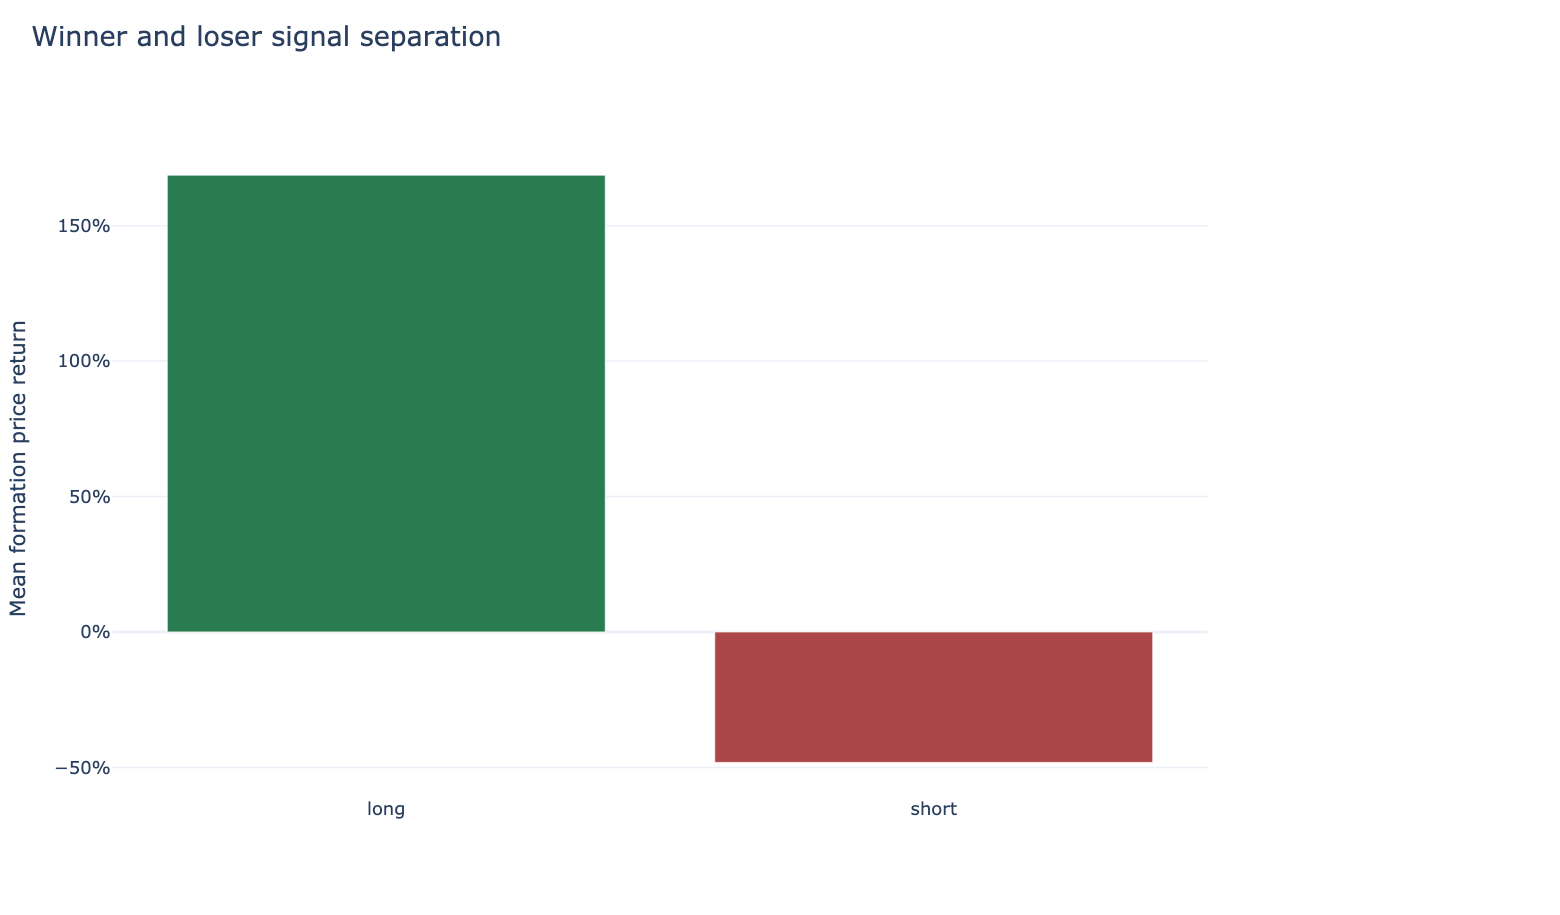

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Academic raw,Borrow 3%,Borrow 6%,Borrow 12%
1M,12,22.8%,19.5%,16.0%,7.7%
1M,24,28.1%,25.0%,21.9%,15.3%
1M,50,23.4%,20.8%,18.0%,12.4%
3M,12,26.4%,23.7%,20.9%,14.9%
3M,24,28.9%,26.3%,23.6%,18.2%
3M,50,23.3%,20.9%,18.5%,13.6%
6M,12,25.6%,23.5%,21.3%,16.9%
6M,24,28.2%,26.2%,24.2%,20.0%
6M,50,24.0%,22.1%,20.1%,16.0%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,16.0%,0.450,-79.6%,14.8%
1M,24,21.9%,0.826,-54.5%,10.6%
1M,50,18.0%,0.758,-53.4%,8.4%
3M,12,20.9%,0.648,-76.4%,10.9%
3M,24,23.6%,0.890,-67.5%,9.7%
3M,50,18.5%,0.721,-69.7%,6.7%
6M,12,21.3%,0.735,-43.8%,8.8%
6M,24,24.2%,1.121,-30.3%,6.1%
6M,50,20.1%,1.120,-34.1%,4.6%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,22.2%,92.8%,1581
1M,24,15.5%,89.7%,1579
1M,50,14.3%,87.6%,1580
3M,12,20.5%,91.9%,1617
3M,24,15.8%,88.4%,927
3M,50,14.8%,88.3%,1043
6M,12,14.0%,90.4%,786
6M,24,9.3%,86.0%,664
6M,50,7.6%,84.5%,582


### CAGR

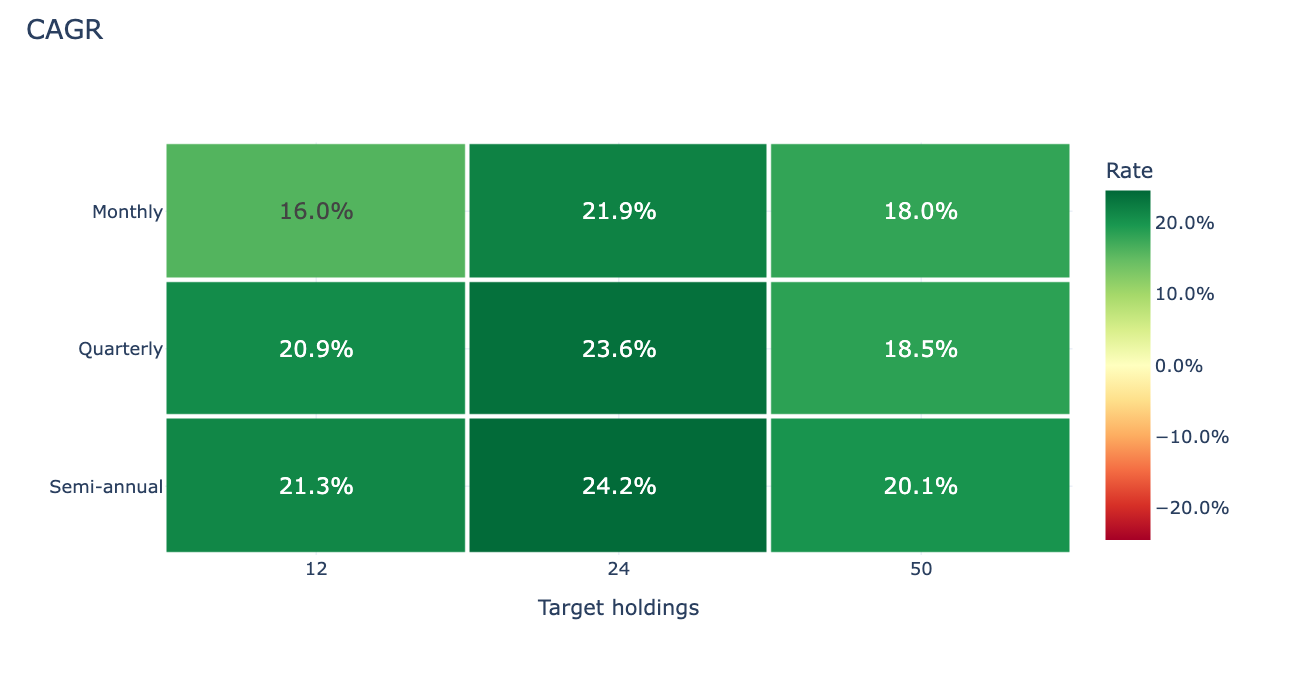

In [5]:
research.heatmap('cagr')

### Sharpe ratio

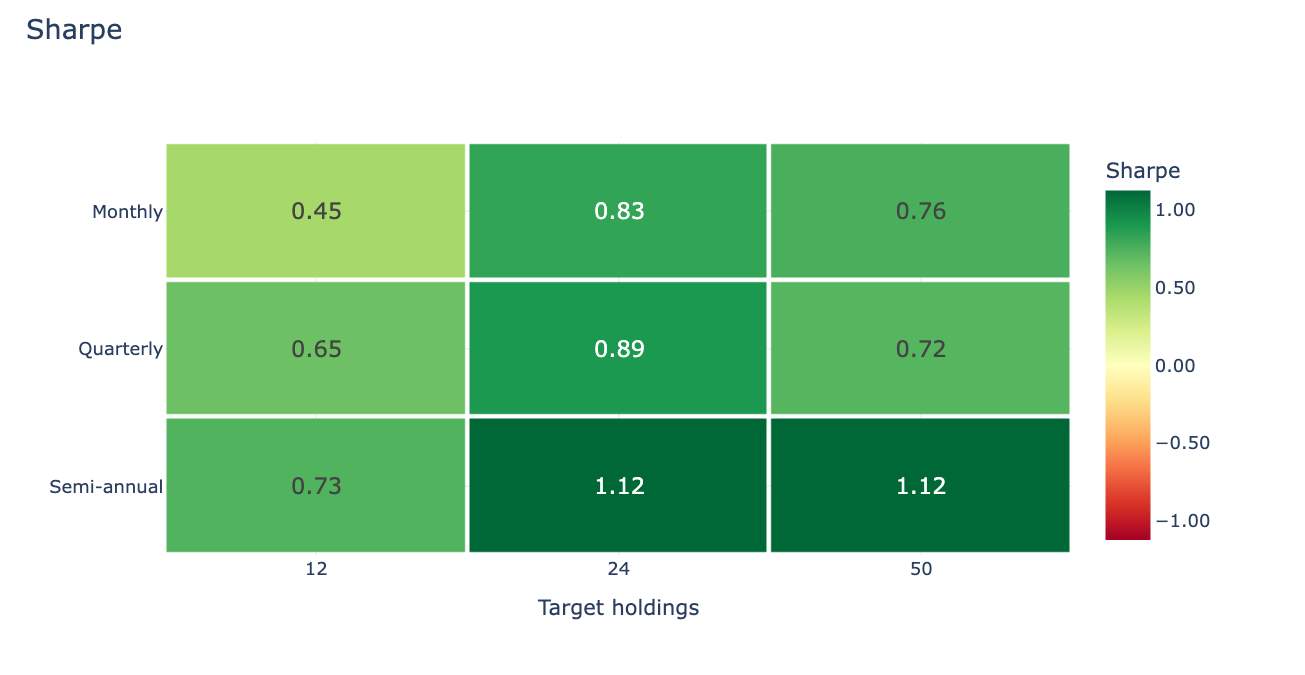

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

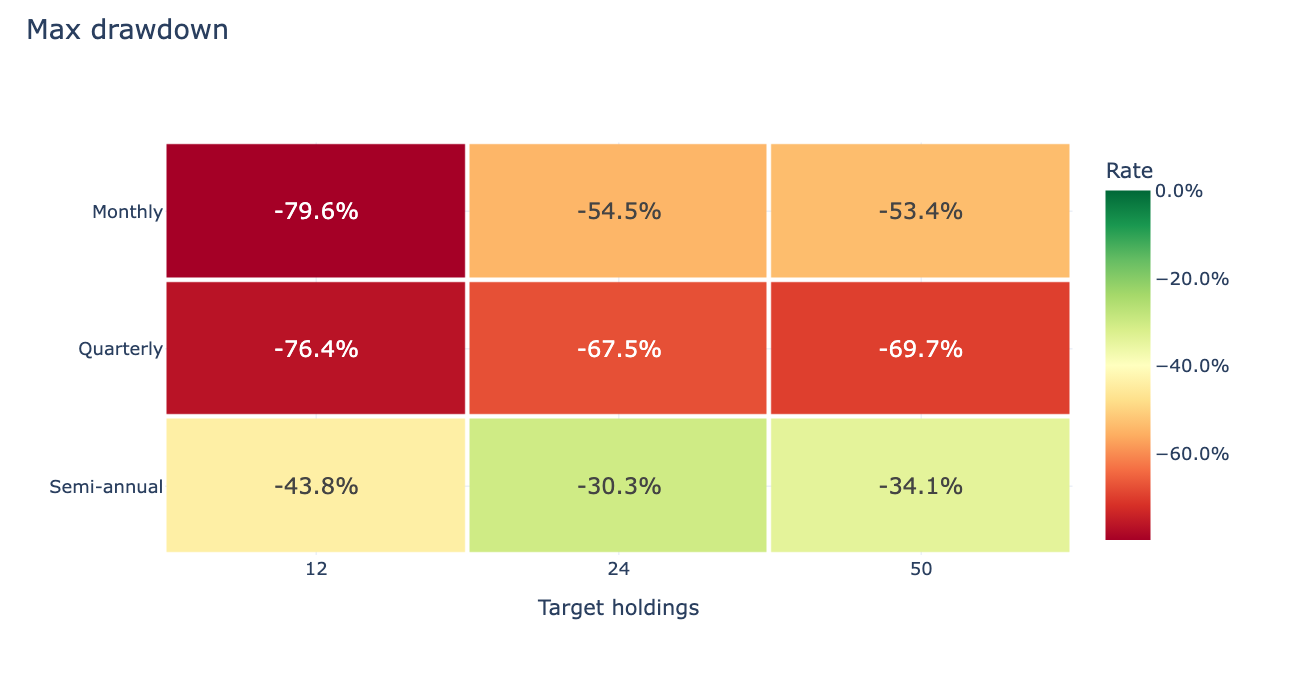

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

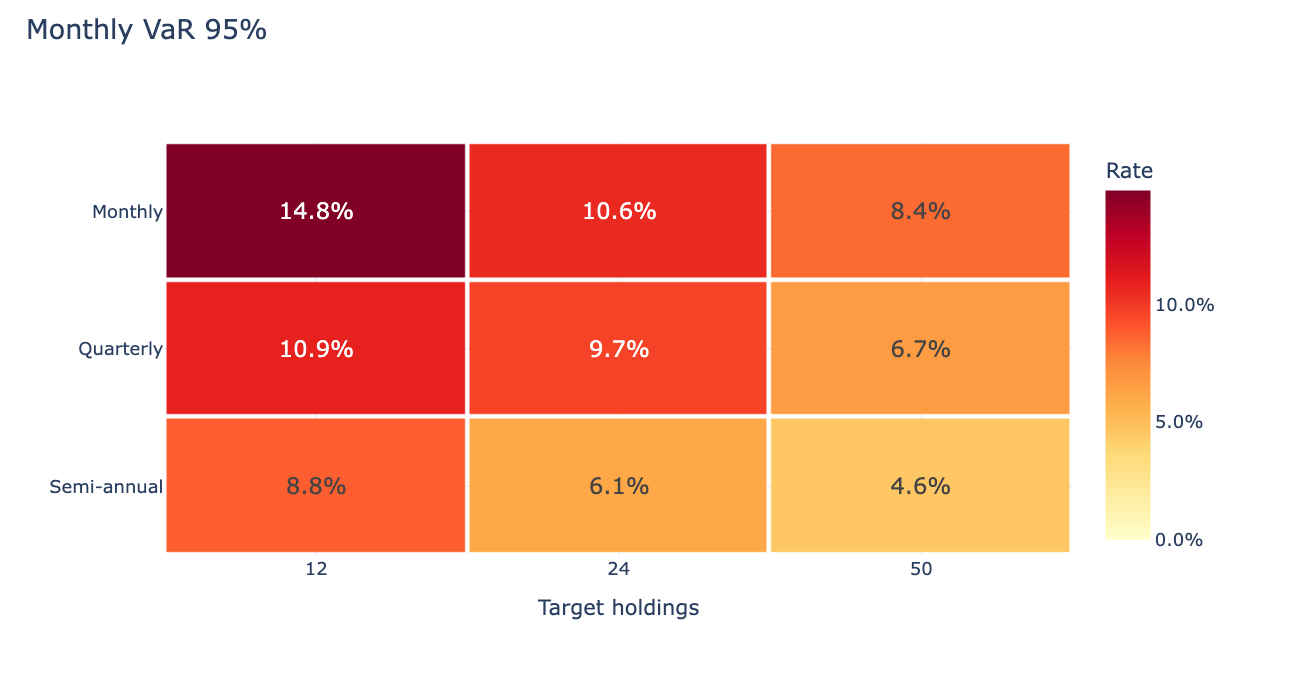

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

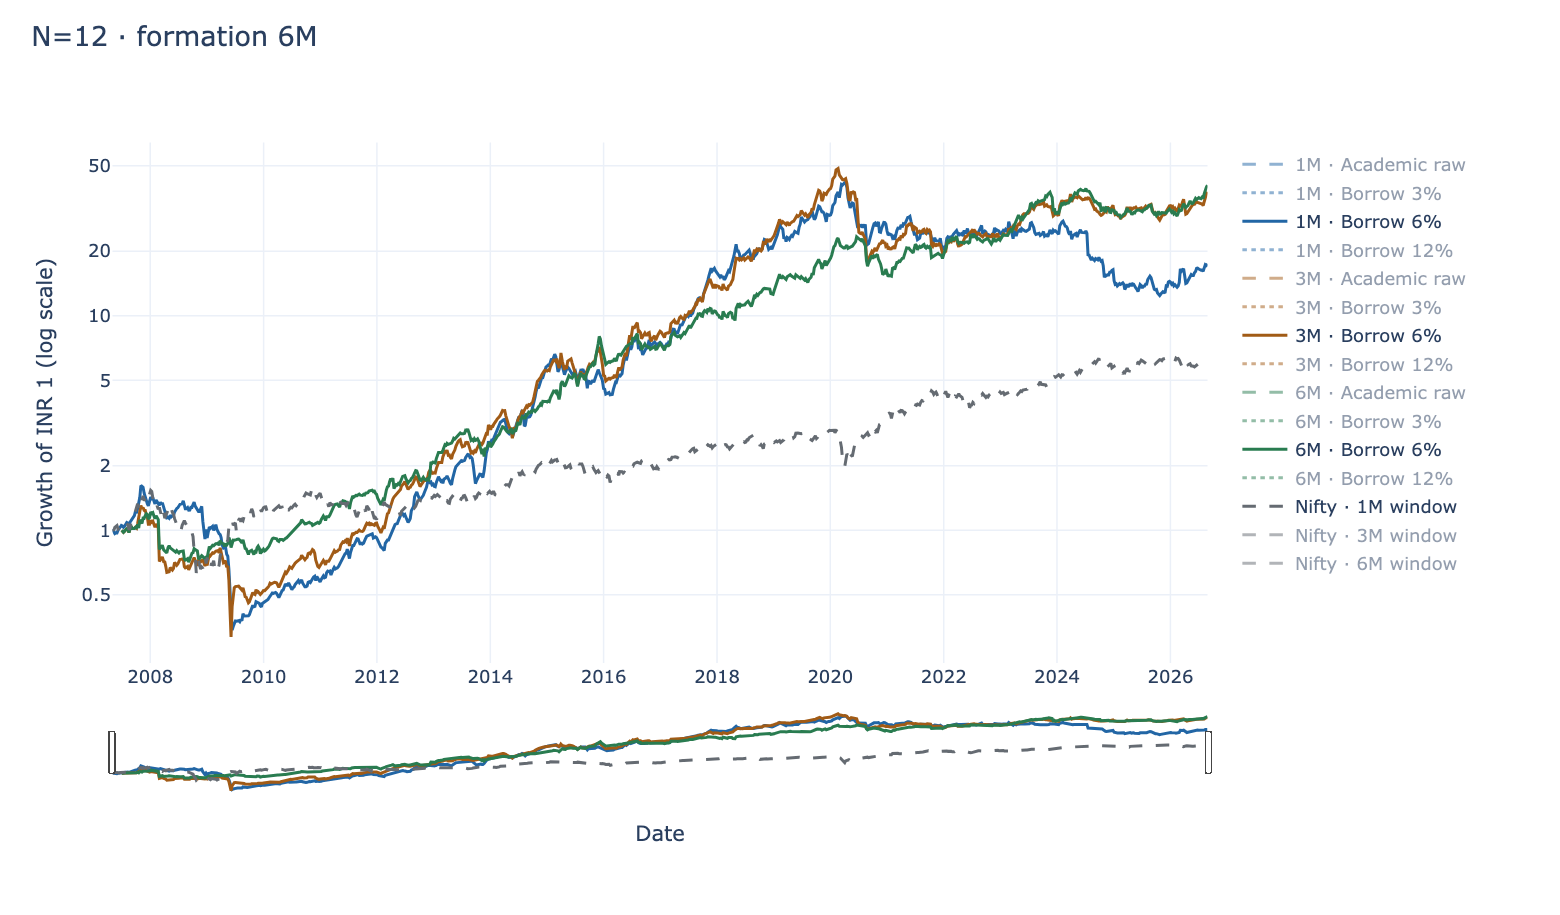

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Academic raw,22.8%,0.691,-78.2%,14.4%
1M,Borrow 3%,19.5%,0.574,-78.9%,14.6%
1M,Borrow 6%,16.0%,0.450,-79.6%,14.8%
1M,Borrow 12%,7.7%,0.156,-86.8%,15.7%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Academic raw,26.4%,0.853,-74.5%,10.5%
3M,Borrow 3%,23.7%,0.752,-75.5%,10.7%
3M,Borrow 6%,20.9%,0.648,-76.4%,10.9%
3M,Borrow 12%,14.9%,0.424,-78.1%,11.5%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Academic raw,21.3%,91.8%,1581
1M,Borrow 3%,21.7%,92.2%,1581
1M,Borrow 6%,22.2%,92.8%,1581
1M,Borrow 12%,23.4%,94.1%,1581
3M,Academic raw,19.9%,90.5%,1508
3M,Borrow 3%,20.2%,91.5%,1617
3M,Borrow 6%,20.5%,91.9%,1617
3M,Borrow 12%,21.1%,92.9%,1617
6M,Academic raw,13.5%,88.7%,739
6M,Borrow 3%,13.7%,89.6%,779


In [9]:
research.equity(12)

### N=24

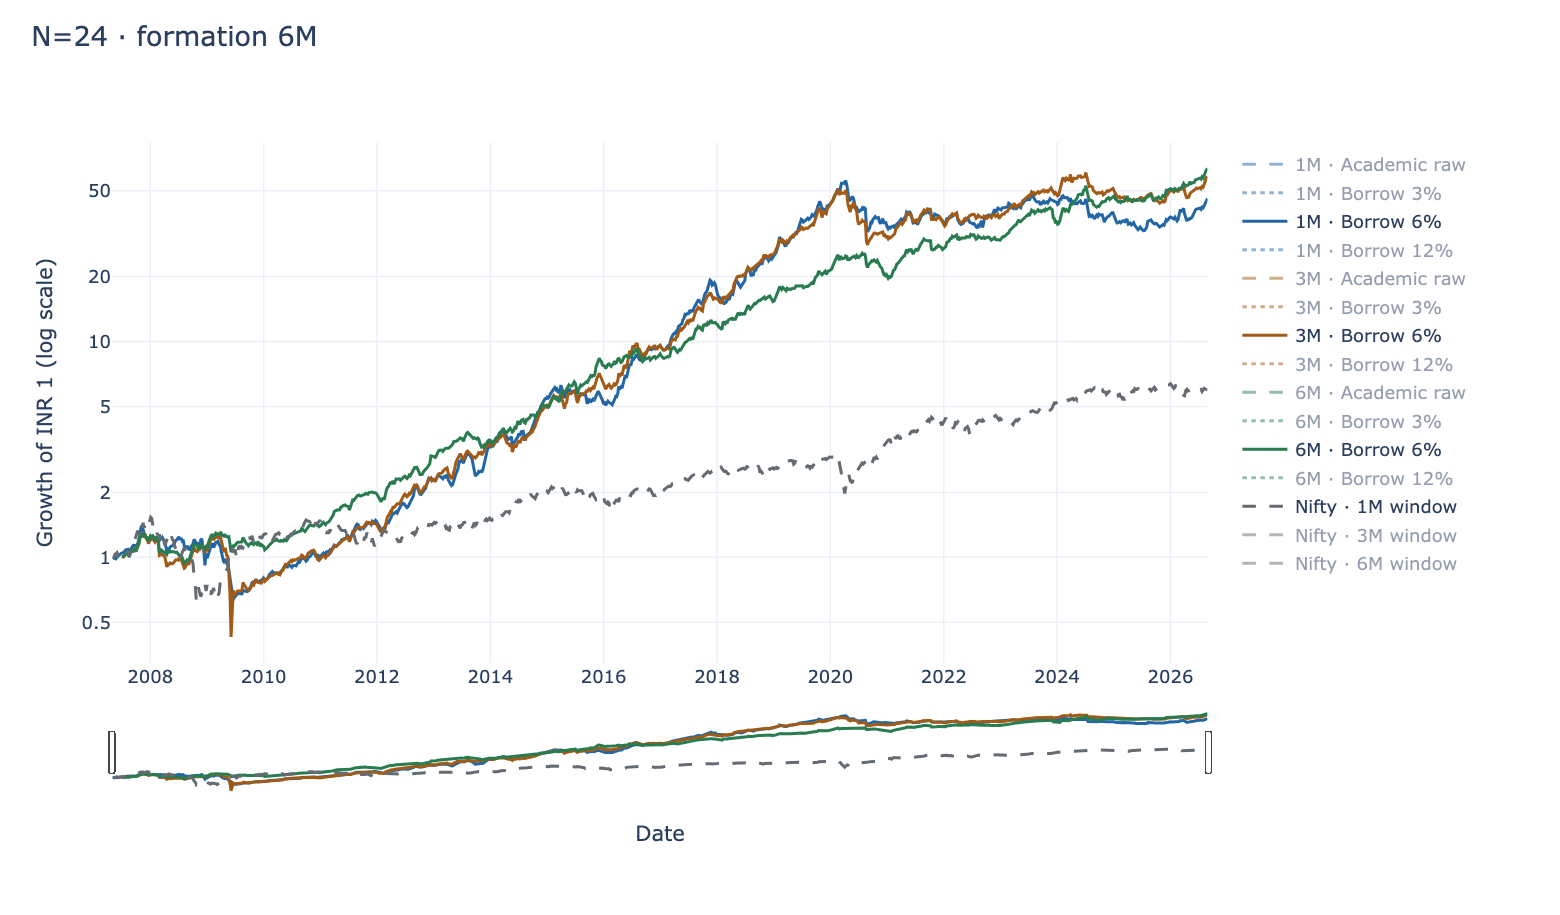

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Academic raw,28.1%,1.118,-51.3%,10.1%
1M,Borrow 3%,25.0%,0.975,-52.9%,10.4%
1M,Borrow 6%,21.9%,0.826,-54.5%,10.6%
1M,Borrow 12%,15.3%,0.502,-62.8%,11.1%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Academic raw,28.9%,1.133,-65.3%,9.1%
3M,Borrow 3%,26.3%,1.013,-66.2%,9.4%
3M,Borrow 6%,23.6%,0.890,-67.5%,9.7%
3M,Borrow 12%,18.2%,0.635,-70.0%,10.4%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Academic raw,14.9%,87.5%,871
1M,Borrow 3%,15.2%,88.9%,1570
1M,Borrow 6%,15.5%,89.7%,1579
1M,Borrow 12%,16.2%,91.3%,1579
3M,Academic raw,15.3%,86.0%,786
3M,Borrow 3%,15.5%,87.2%,883
3M,Borrow 6%,15.8%,88.4%,927
3M,Borrow 12%,16.3%,90.1%,1610
6M,Academic raw,8.9%,83.8%,348
6M,Borrow 3%,9.1%,84.9%,362


In [10]:
research.equity(24)

### N=50

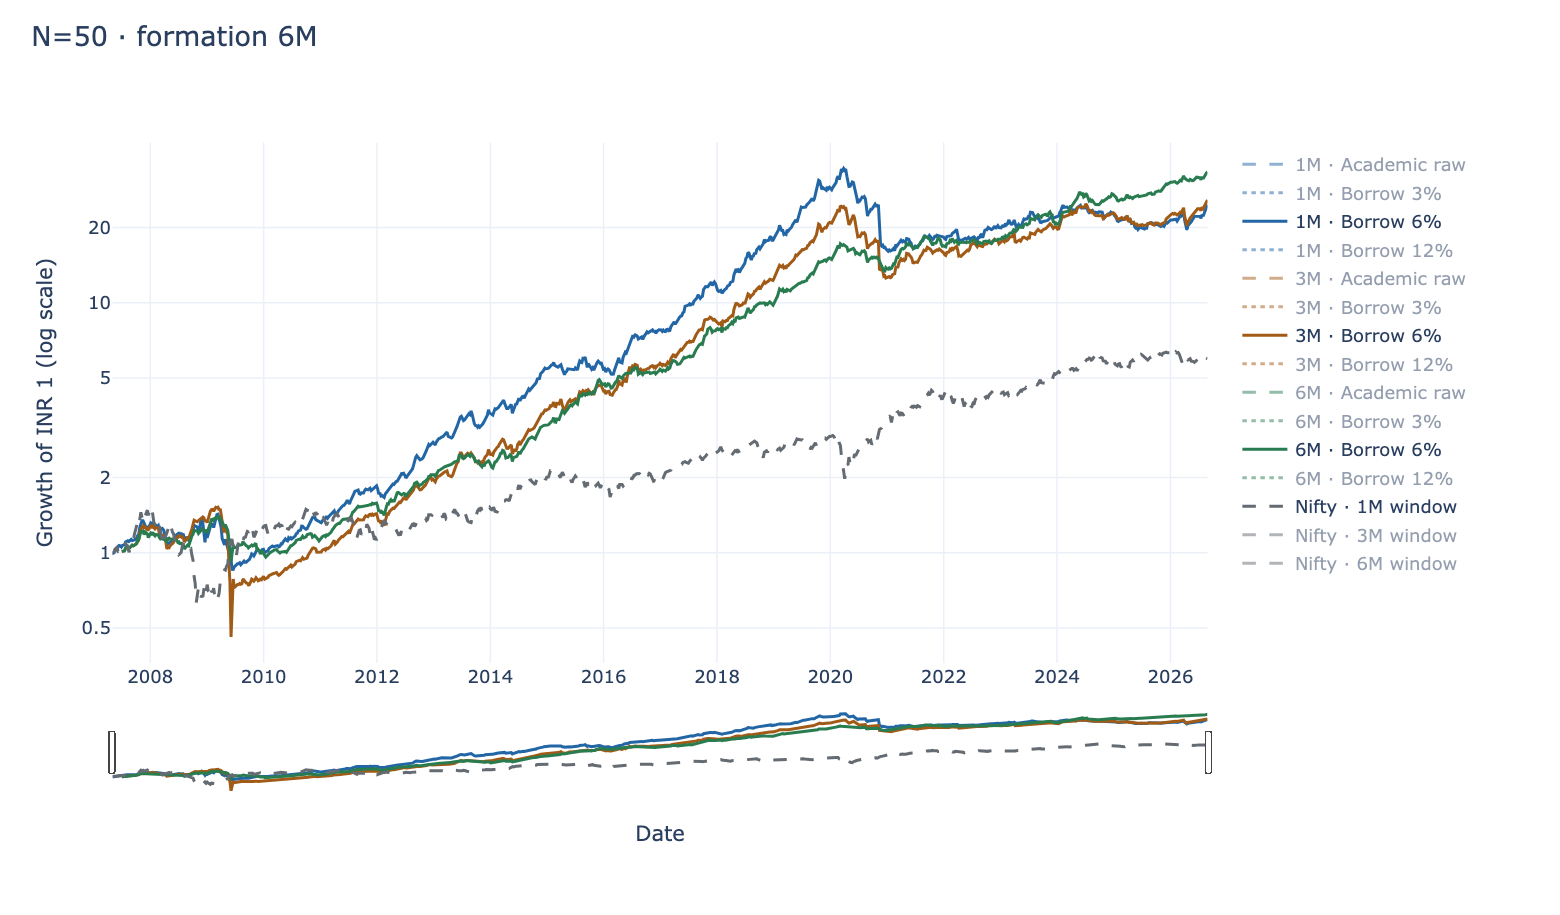

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Academic raw,23.4%,1.083,-50.5%,8.0%
1M,Borrow 3%,20.8%,0.922,-51.9%,8.2%
1M,Borrow 6%,18.0%,0.758,-53.4%,8.4%
1M,Borrow 12%,12.4%,0.409,-62.0%,8.8%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Academic raw,23.3%,0.984,-68.8%,6.3%
3M,Borrow 3%,20.9%,0.853,-69.3%,6.5%
3M,Borrow 6%,18.5%,0.721,-69.7%,6.7%
3M,Borrow 12%,13.6%,0.448,-70.7%,7.1%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Academic raw,13.8%,85.9%,1571
1M,Borrow 3%,14.0%,86.6%,1580
1M,Borrow 6%,14.3%,87.6%,1580
1M,Borrow 12%,14.8%,89.5%,1584
3M,Academic raw,14.3%,85.4%,910
3M,Borrow 3%,14.5%,86.9%,966
3M,Borrow 6%,14.8%,88.3%,1043
3M,Borrow 12%,15.3%,90.3%,1598
6M,Academic raw,7.2%,81.7%,510
6M,Borrow 3%,7.4%,83.0%,536


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2020-04-09,2020-09-01,Not recovered,1579,2329,-43.9%
3M,2007-11-05,2009-06-05,2011-08-08,927,1371,-67.5%
6M,2007-11-15,2008-08-11,2010-08-04,664,992,-30.3%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

In [13]:
research.behavior()

Rebalance,N,Mean long exposure,Mean short exposure,Borrow fees (INR)
1M,12,77.4%,104.0%,"178,175,877.28"
1M,24,68.1%,87.4%,"230,728,037.66"
1M,50,64.5%,77.6%,"117,021,346.72"
3M,12,65.0%,79.0%,"158,262,619.82"
3M,24,62.7%,72.0%,"184,559,725.40"
3M,50,61.4%,68.4%,"80,581,235.34"
6M,12,58.8%,61.1%,"97,397,546.60"
6M,24,55.9%,56.7%,"113,717,199.79"
6M,50,56.2%,56.7%,"67,011,514.85"


## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

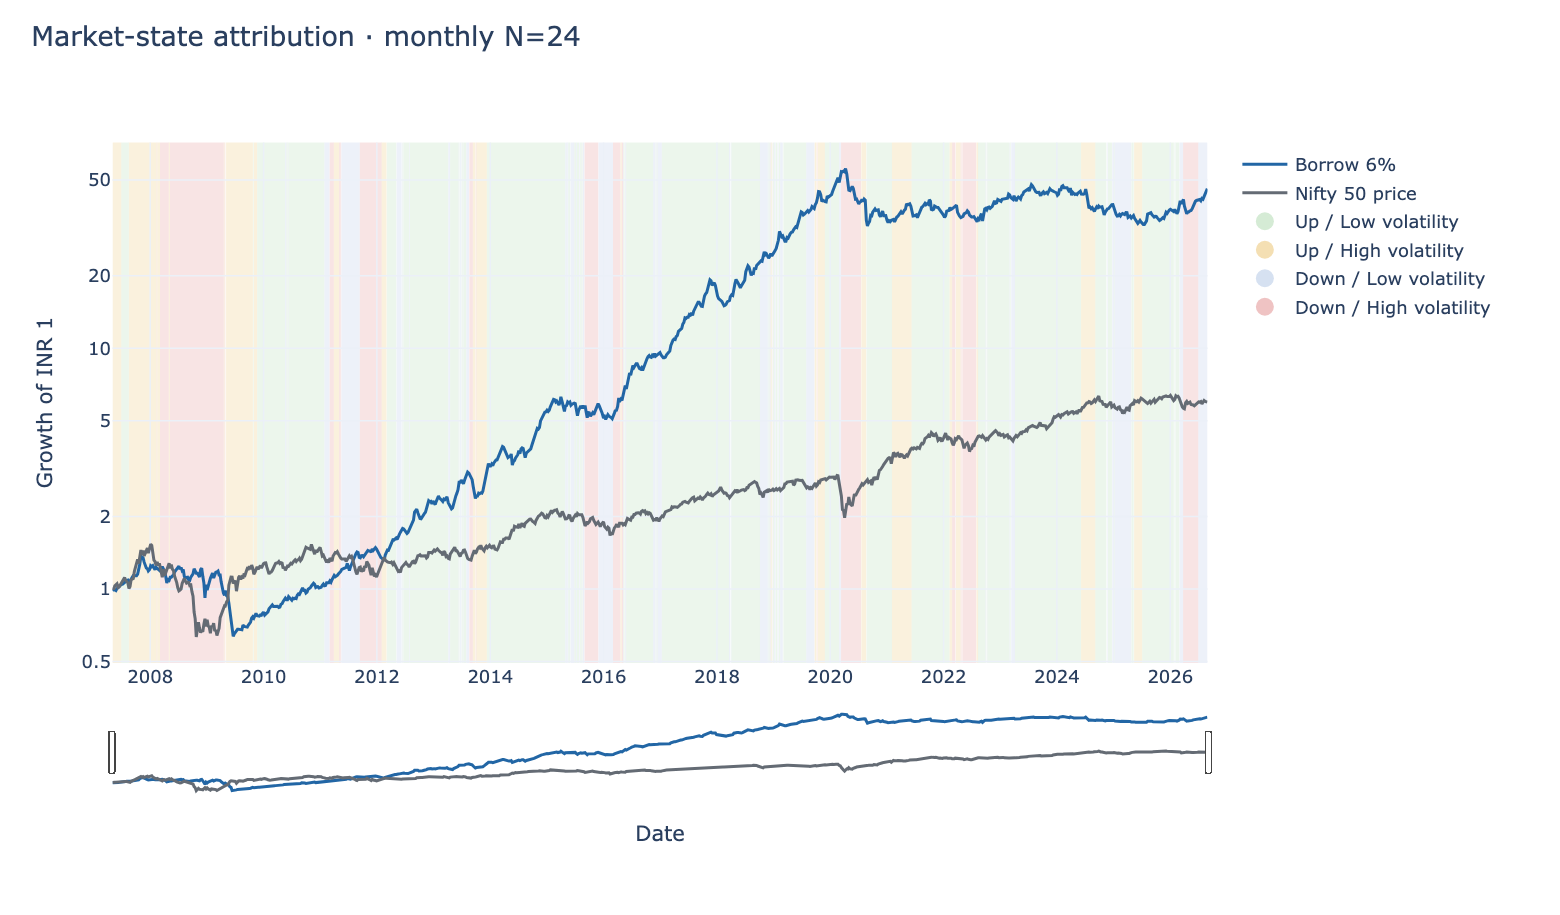

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.02%,1.23%,52.94%
Down / Low volatility,609,0.09%,1.01%,54.52%
Up / High volatility,720,-0.02%,1.45%,52.92%
Up / Low volatility,2694,0.14%,1.01%,58.09%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,6312
1M,24,2007-05-03,2026-08-03,232,11247
1M,50,2007-05-03,2026-08-03,232,19934
3M,12,2007-07-02,2026-07-01,77,1806
3M,24,2007-07-02,2026-07-01,77,3411
3M,50,2007-07-02,2026-07-01,77,6139
6M,12,2007-07-02,2026-07-01,39,892
6M,24,2007-07-02,2026-07-01,39,1601
6M,50,2007-07-02,2026-07-01,39,3026


## Findings

In [16]:
research.conclusion()